# 05 · Modelling — comparación de algoritmos

Entrenamos y comparamos **tres clasificadores** sobre el set de features
seleccionado (`churn_dataset_features.csv`):

| Modelo | Tipo |
|---|---|
| **Regresión Logística** | modelo lineal (baseline de los papers) |
| **Random Forest** | bagging de árboles |
| **XGBoost** | gradient boosting |

## Manejo del desbalance (sin resampling)

Siguiendo los papers (Gattermann-Itschert & Thonemann), **no** usamos under/over-
sampling — eso cambia el tamaño de muestra que el multi-slicing busca aprovechar.
Usamos **aprendizaje sensible al costo**:
- LogReg / RF: `class_weight='balanced'`
- XGBoost: `scale_pos_weight = neg/pos`

La Regresión Logística, sensible a la escala, se envuelve en un `Pipeline` con
`StandardScaler` que se ajusta **solo en train** dentro de cada fold (los modelos
de árboles no se escalan, son invariantes a la escala).

## Evaluación: los dos protocolos

Cada modelo se evalúa con **GroupKFold por vendedora** (generalización honesta) y
con el **split OOT** (producción). Hiperparámetros modestos y comparables; el
tuning fino va en un paso posterior.


## 0 · Setup, datos y split

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent
df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv", parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values
print(f"dataset: {df.shape[0]:,} filas | {len(FEATS)} features | prevalencia churn {y.mean():.3f}")


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
spw = (y[train_mask] == 0).sum() / (y[train_mask] == 1).sum()   # scale_pos_weight para XGB
print(f"train {train_mask.sum():,} | test {test_mask.sum():,} | scale_pos_weight={spw:.2f}")

dataset: 30,821 filas | 71 features | prevalencia churn 0.309
train 28,735 | test 885 | scale_pos_weight=2.22


## 1 · Definición de los modelos (desbalance vía pesos)

In [2]:
def make_models():
    return {
        # baseline lineal: escalado dentro del pipeline (fit-en-train, sin leakage)
        "LogReg": make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
        "RandomForest": RandomForestClassifier(
            n_estimators=400, max_depth=8, class_weight="balanced",
            n_jobs=-1, random_state=42),
        "XGBoost": XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
            eval_metric="logloss", tree_method="hist", n_jobs=-1, random_state=42),
    }

print("Modelos:", list(make_models().keys()))

Modelos: ['LogReg', 'RandomForest', 'XGBoost']


## 2 · Evaluación con los dos protocolos

Para cada modelo:
- **GroupKFold (5)**: predicciones out-of-fold → AUC, PR-AUC, lift del decil top.
- **OOT**: fit en train, predecir test → AUC (+ std por mes), F1/precision/recall
  a t=0.5, lift del decil top.


In [3]:
def top_decile_lift(yt, p):
    k = max(len(yt) // 10, 1)
    sel = np.argsort(-p)[:k]
    return yt[sel].mean() / yt.mean()

def eval_model(name, model):
    # --- GroupKFold ---
    oof = cross_val_predict(model, X, y, cv=GroupKFold(5), groups=groups,
                            method="predict_proba", n_jobs=None)[:, 1]
    g_auc = roc_auc_score(y, oof); g_ap = average_precision_score(y, oof)
    g_lift = top_decile_lift(y, oof)
    # --- OOT ---
    m = model; m.fit(X[train_mask], y[train_mask])
    p = m.predict_proba(X[test_mask])[:, 1]; yt = y[test_mask]
    pr = (p >= 0.5).astype(int)
    o_auc = roc_auc_score(yt, p)
    # std de AUC por mes del test
    dft = df[test_mask].copy(); dft["p"] = p
    aucs = [roc_auc_score(g["churn"], g["p"]) for _, g in
            dft.groupby(dft["mes_obs"].dt.strftime("%Y-%m")) if g["churn"].nunique() > 1]
    return {
        "gkf_AUC": g_auc, "gkf_PRAUC": g_ap, "gkf_lift10": g_lift,
        "oot_AUC": o_auc, "oot_AUCstd": np.std(aucs),
        "oot_F1": f1_score(yt, pr, zero_division=0),
        "oot_prec": precision_score(yt, pr, zero_division=0),
        "oot_rec": recall_score(yt, pr),
        "oot_lift10": top_decile_lift(yt, p),
    }

rows = {}
for name, model in make_models().items():
    print(f"evaluando {name} ...")
    rows[name] = eval_model(name, model)
res = pd.DataFrame(rows).T
print("\nlisto")

evaluando LogReg ...


evaluando RandomForest ...


evaluando XGBoost ...



listo


## 3 · Comparación

In [4]:
cols = ["gkf_AUC", "gkf_PRAUC", "gkf_lift10", "oot_AUC", "oot_AUCstd",
        "oot_F1", "oot_prec", "oot_rec", "oot_lift10"]
tabla = res[cols].sort_values("oot_AUC", ascending=False)
print(tabla.round(4).to_string())

best = tabla["oot_AUC"].idxmax()
best_gkf = tabla["gkf_AUC"].idxmax()
print(f"\nMejor por AUC OOT:       {best} ({tabla.loc[best,'oot_AUC']:.4f})")
print(f"Mejor por AUC GroupKFold: {best_gkf} ({tabla.loc[best_gkf,'gkf_AUC']:.4f})")

              gkf_AUC  gkf_PRAUC  gkf_lift10  oot_AUC  oot_AUCstd  oot_F1  oot_prec  oot_rec  oot_lift10
RandomForest   0.7450     0.5344      2.0238   0.7657      0.0276  0.5549    0.4515   0.7195      2.3302
LogReg         0.7431     0.5279      1.9818   0.7637      0.0046  0.5625    0.4569   0.7317      2.2076
XGBoost        0.7454     0.5357      1.9944   0.7569      0.0250  0.5488    0.4390   0.7317      2.3302

Mejor por AUC OOT:       RandomForest (0.7657)
Mejor por AUC GroupKFold: XGBoost (0.7454)


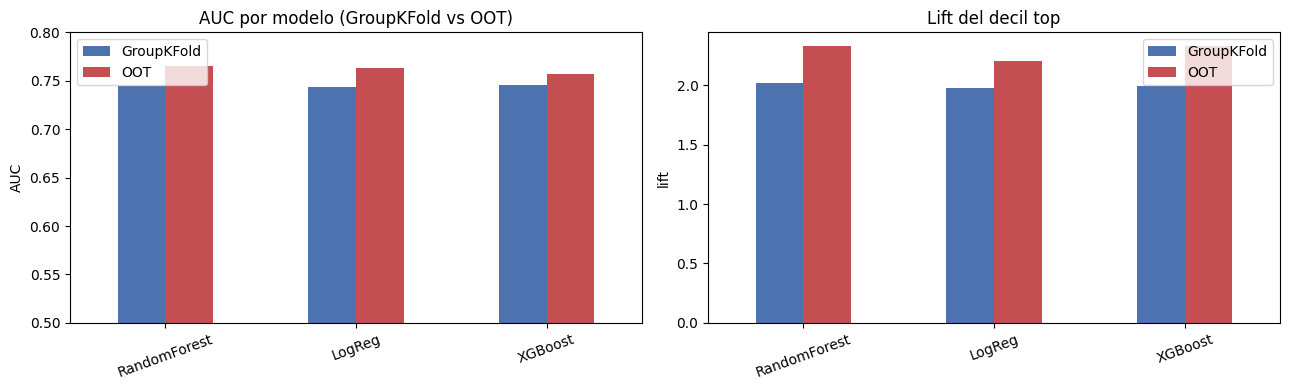

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
res.loc[tabla.index, ["gkf_AUC", "oot_AUC"]].plot.bar(ax=ax[0], color=["#4c72b0", "#c44e52"])
ax[0].set_title("AUC por modelo (GroupKFold vs OOT)"); ax[0].set_ylim(0.5, 0.8)
ax[0].set_ylabel("AUC"); ax[0].tick_params(axis="x", rotation=20); ax[0].legend(["GroupKFold", "OOT"])
res.loc[tabla.index, ["gkf_lift10", "oot_lift10"]].plot.bar(ax=ax[1], color=["#4c72b0", "#c44e52"])
ax[1].set_title("Lift del decil top"); ax[1].set_ylabel("lift")
ax[1].tick_params(axis="x", rotation=20); ax[1].legend(["GroupKFold", "OOT"])
plt.tight_layout(); plt.show()

## 4 · Síntesis

_(Tabla y ganador en la sección 3, arriba — generada al ejecutar.)_

- **Modelo lineal competitivo:** la Regresión Logística iguala (o supera en AUC OOT)
  a los modelos de árboles, confirmando el **techo de señal** del problema (~0.77) y
  la calidad de las features (la señal es mayormente lineal/monótona).
- **Random Forest y XGBoost** quedan en empate técnico con el baseline lineal.
- **Decisión:** llevar **XGBoost** al tuning de hiperparámetros (Optuna, validación
  cruzada anidada) por su madurez y amplia adopción en la literatura de churn.

**Próximo paso:** `02_tuning_xgboost_optuna`.